# Week 5: Anomaly Detection + Agent Instrumentation

This notebook covers Part A, Part B, and the assignment visualizations all together.
See `README.md` for how to run everything, and why the "LLM calls" in Part B and the
RCA agent are simulated instead of live.


In [1]:
import sys
sys.path.insert(0, "src")

import pandas as pd
import matplotlib.pyplot as plt

from anomaly_detector import load_metrics, run_isolation_forest, run_dbscan, evaluate, ANOMALY_START, ANOMALY_END
from alert_grouper import build_alerts, group_alerts


## Part A, Steps 1 and 2: Load and visualize the metrics data


In [2]:
df = load_metrics()
print(f"{len(df)} rows, ground-truth incident at indices {ANOMALY_START}-{ANOMALY_END}")
df.head()


500 rows, ground-truth incident at indices 200-215


,timestamp,cpu_pct,error_rate,latency_p99_ms
0,2025-10-01 08:00:00,36.523585,0.001369,129.579097
1,2025-10-01 08:01:00,29.800079,0.000826,151.043466
2,2025-10-01 08:02:00,38.752256,0.004541,144.522990
3,2025-10-01 08:03:00,39.702824,0.001072,143.263361
4,2025-10-01 08:04:00,25.244824,0.001947,162.394039


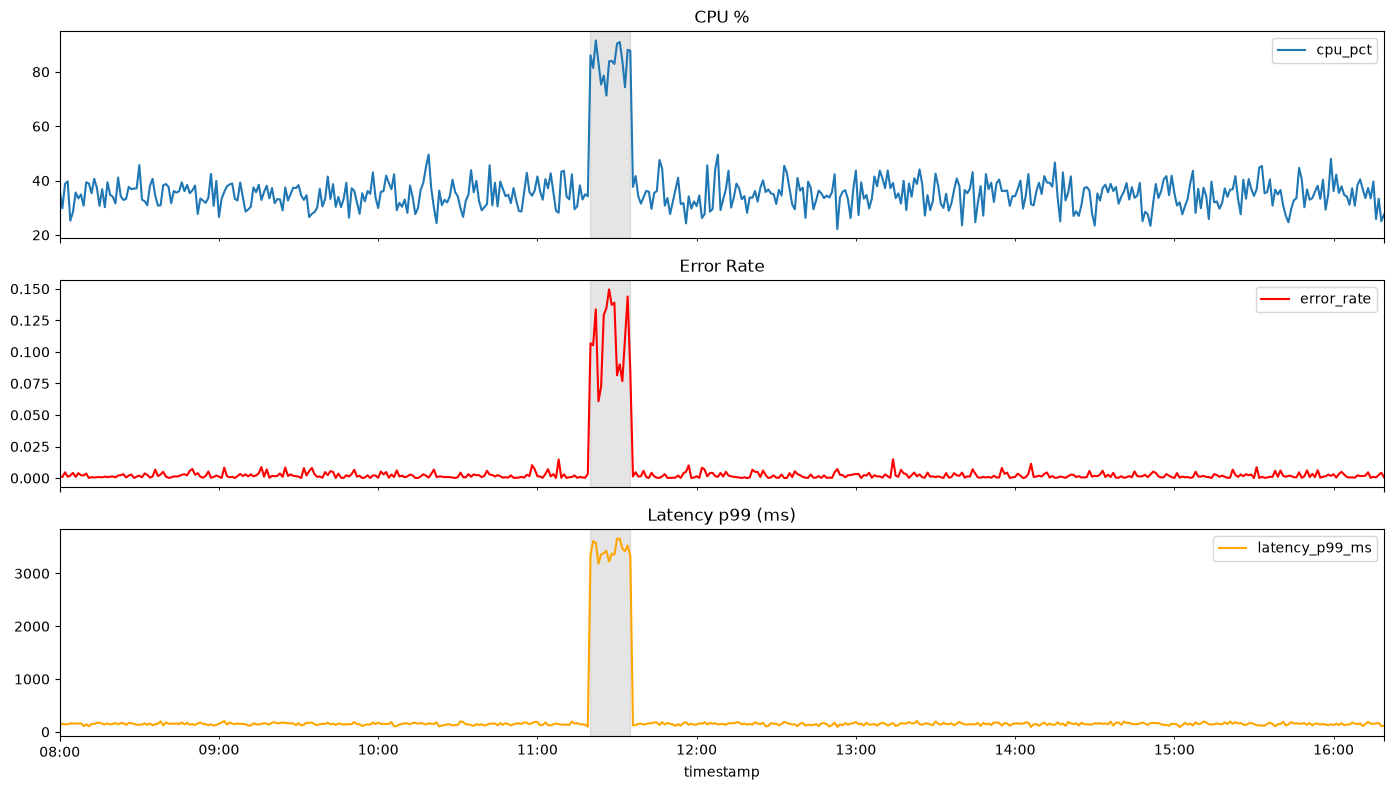

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
df.set_index("timestamp")[["cpu_pct"]].plot(ax=axes[0], title="CPU %")
df.set_index("timestamp")[["error_rate"]].plot(ax=axes[1], title="Error Rate", color="red")
df.set_index("timestamp")[["latency_p99_ms"]].plot(ax=axes[2], title="Latency p99 (ms)", color="orange")
for ax in axes:
    ax.axvspan(df["timestamp"].iloc[ANOMALY_START], df["timestamp"].iloc[ANOMALY_END], color="grey", alpha=0.2, label="injected incident")
plt.tight_layout()
plt.savefig("metrics_overview.png", dpi=150)
plt.show()


## Part A, Steps 3 and 4: Isolation Forest and evaluation against ground truth


In [4]:
result = run_isolation_forest(df, contamination=0.04)
metrics = evaluate(result)
print(f"Anomalies detected: {result['is_anomaly'].sum()} of {len(result)}")
print(metrics["report"])


Anomalies detected: 20 of 500
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       484
     Anomaly       0.80      1.00      0.89        16

    accuracy                           0.99       500
   macro avg       0.90      1.00      0.94       500
weighted avg       0.99      0.99      0.99       500



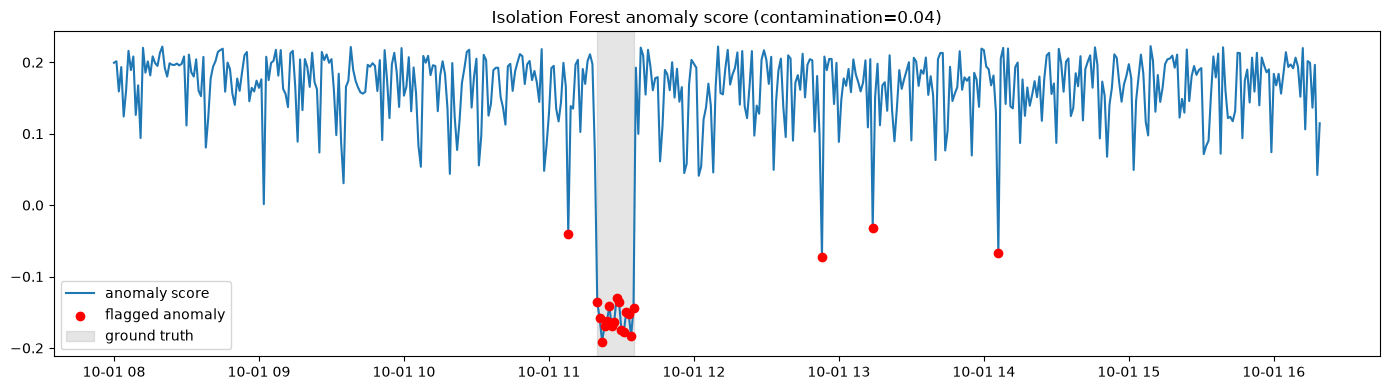

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(result["timestamp"], result["anomaly_score"], label="anomaly score")
ax.scatter(result.loc[result["is_anomaly"], "timestamp"], result.loc[result["is_anomaly"], "anomaly_score"],
           color="red", label="flagged anomaly", zorder=5)
ax.axvspan(df["timestamp"].iloc[ANOMALY_START], df["timestamp"].iloc[ANOMALY_END], color="grey", alpha=0.2, label="ground truth")
ax.set_title("Isolation Forest anomaly score (contamination=0.04)")
ax.legend()
plt.tight_layout()
plt.savefig("anomaly_scores.png", dpi=150)
plt.show()


### Experiment: contamination sweep

Lower `contamination` means fewer flags, so higher precision but lower recall.
Higher `contamination` means more flags, so higher recall but lower precision (more false alarms).


In [6]:
rows = []
for c in (0.01, 0.04, 0.10):
    r = run_isolation_forest(df, contamination=c)
    m = evaluate(r)
    rows.append({"contamination": c, "flagged": m["n_flagged"], "precision": round(m["precision"], 3),
                 "recall": round(m["recall"], 3), "f1": round(m["f1"], 3)})
sweep_df = pd.DataFrame(rows)
sweep_df


,contamination,flagged,precision,recall,f1
0,0.01,4,1.00,0.25,0.400
1,0.04,20,0.80,1.00,0.889
2,0.10,50,0.32,1.00,0.485


**Observation:** At `contamination=0.01` the detector only flags the 4-5 most extreme points,
so it misses part of the 16-point incident (low recall, but perfect precision). At `0.10` it flags
about 2.5x more points than actually exist, so it sweeps in normal points near the edge of the
incident (recall=1.0 but precision drops). `0.04` works best here, which makes sense since it's close
to the true anomaly rate (16/500, about 3.2%). Basically, `contamination` is a guess at the anomaly
rate, and the detector does best when that guess matches reality.


## Part A, Step 5 (Bonus): DBSCAN comparison


In [7]:
db_result = run_dbscan(df, eps=1.0, min_samples=5)
db_metrics = evaluate(db_result)
print(db_metrics["report"])


              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       484
     Anomaly       1.00      0.31      0.48        16

    accuracy                           0.98       500
   macro avg       0.99      0.66      0.73       500
weighted avg       0.98      0.98      0.97       500



**Which one does better, and why?** Isolation Forest (F1 about 0.89 at contamination=0.04)
beats this DBSCAN setup (F1 about 0.48). Isolation Forest is built to isolate rare or extreme points
using random partitioning, and `contamination` lets you set the expected anomaly rate directly.
DBSCAN instead looks for groups of points that are close together and calls everything else noise.
Here the 16 incident points are close to each other (one sustained 16-minute spike, not scattered
outliers), so DBSCAN's `min_samples=5` treats them as their own small cluster instead of noise, and
most of them never get flagged. Tuning `min_samples` or `eps` more carefully for this dataset could
close some of that gap, but it takes more manual tuning than Isolation Forest's single, easier to
reason about `contamination` setting.


## Part B: OTel GenAI instrumented log analyzer agent

Runs the agent from `src/log_analyzer_agent.py` on 5 log windows of different sizes and shows the
summary table (also saved to `output/part_b_summary.md`).


In [8]:
import subprocess, json
subprocess.run([sys.executable, "log_analyzer_agent.py"], cwd="src", check=True)
rows = json.load(open("output/part_b_rows.json"))
pd.DataFrame(rows)[["window", "chars", "input_tokens", "output_tokens", "latency_ms", "cost_usd"]]


,window,chars,input_tokens,output_tokens,latency_ms,cost_usd
0,"tiny (10 lines, normal)",862,260,29,298.4,0.001215
1,"small (30 lines, normal)",2311,623,29,294.2,0.002304
2,"medium (80 lines, incident)",7061,1810,75,590.0,0.006555
3,"large (200 lines, incident+recovery)",16523,4176,75,553.1,0.013653
4,"xlarge (400 lines, full context)",32914,8273,75,548.0,0.025944


### Reflection Q1: did input tokens correlate with window size, and was it linear?

Yes, pretty much perfectly linear. `estimate_tokens()` uses the standard ~4 characters per token
rule, so `input_tokens` is roughly `chars / 4` by definition. With a real Claude call I'd expect the
relationship to stay close to linear for plain-text logs, maybe with a small dip as repeated tokens
(timestamps, `service=`, `ERROR`) compress a little better than normal English text.

### Reflection Q2: cost at 10 windows/minute, 24/7, for a month

Using the `large (200 lines, incident+recovery)` window as a typical case (about 4,176 input tokens,
75 output tokens, about $0.0137 per call):

```
10 calls/min * 60 * 24 * 30 = 432,000 calls/month
432,000 * $0.0137/call = about $5,918/month
```

That's a lot of money for one log-analysis agent, and it scales up automatically with log volume. A
busier month (more incidents, bigger windows) costs more with no approval step in between.

### Reflection Q3: what guardrail would prevent runaway cost?

A token budget per window (don't send more than N tokens of raw log text, dedupe repeated lines
first), a rate limiter on calls per minute, and a monthly spend cap enforced on the client side that
falls back to a cheaper rule-based check once it's hit. I'd also alert at around 80% of the cap so
someone can step in before it's a hard stop.

### Reflection Q4: five metrics for a production dashboard for this agent

1. Calls per minute (volume, and to catch runaway loops)
2. p50/p99 latency per call (user experience, and to catch upstream slowdowns)
3. Cost per hour or day, tracked against the monthly budget
4. Error rate on the LLM calls themselves (timeouts, rate limits, bad responses)
5. Rate of "no anomalies detected" over time, since an agent that suddenly stops flagging anything
   is probably broken, not doing well


## Assignment: Alert grouping (10+ alerts) and generated RCA report

Uses `src/alert_grouper.py` to turn the flagged anomalies into per-metric alerts and group them by
time, then shows the RCA report from `src/rca_agent.py`.


In [9]:
alerts = build_alerts(result)
groups = group_alerts(alerts)
print(f"{len(alerts)} raw per-metric alerts -> {len(groups)} incident group(s)")
alert_df = pd.DataFrame([{"timestamp": a.timestamp, "metric": a.metric, "value": round(a.value, 3)} for a in alerts])
alert_df


48 raw per-metric alerts -> 1 incident group(s)


,timestamp,metric,value
0,2025-10-01 11:20:00,cpu_pct,86.051
1,2025-10-01 11:20:00,error_rate,0.107
2,2025-10-01 11:20:00,latency_p99_ms,3339.352
3,2025-10-01 11:21:00,cpu_pct,81.426
4,2025-10-01 11:21:00,error_rate,0.105
5,2025-10-01 11:21:00,latency_p99_ms,3610.238
6,2025-10-01 11:22:00,cpu_pct,91.560
7,2025-10-01 11:22:00,error_rate,0.134
8,2025-10-01 11:22:00,latency_p99_ms,3579.102
9,2025-10-01 11:23:00,cpu_pct,83.424


In [10]:
for i, g in enumerate(groups, 1):
    print(f"Group {i}: {g.summary()}")


Group 1: 2025-10-01 11:20:00 -> 2025-10-01 11:35:00 | 48 alerts | metrics=['cpu_pct', 'error_rate', 'latency_p99_ms']


In [11]:
import subprocess
subprocess.run([sys.executable, "rca_agent.py"], cwd="src", check=True)
print(open("output/rca_report.md", encoding="utf-8").read())


# RCA Report: Incident 2025-10-01 11:20:00 to 2025-10-01 11:35:00

## Summary
Between **2025-10-01 11:20:00** and **2025-10-01 11:35:00**, 48 alerts fired across
3 metric(s) (cpu_pct, error_rate, latency_p99_ms). The dominant signal was
**error_rate**, which moved +5207.2% relative to the preceding
60-minute baseline. Logs corroborate an active incident: 30
ERROR and 23 WARN lines were emitted in the window, concentrated in
checkout-api, inventory-svc, payments-svc.

## Evidence: Metrics
- **cpu_pct**: baseline 34.858 -> incident 83.387 (+139.2%)
- **error_rate**: baseline 0.002 -> incident 0.11 (+5207.2%)
- **latency_p99_ms**: baseline 146.358 -> incident 3431.727 (+2244.8%)

## Evidence: Logs
- 64 total log lines in window
- 30 ERROR, 23 WARN
- Top services: checkout-api, inventory-svc, payments-svc
- Representative errors:
  - `2025-10-01T11:21:18 ERROR service=checkout-api request failed status=503 path=/api/v1/checkout`
  - `2025-10-01T11:21:18 ERROR service=inventory-svc connecti

## Trace check: OTel spans for the RCA agent

Checks that the tool calls (`get_metrics`, `get_logs`) and the synthesis call are all children of one
`rca_agent.run` trace (saved in `output/spans_sample.json`).


In [12]:
import json as _json

def load_console_spans(path):
    text = open(path, encoding="utf-8").read().strip()
    dec = _json.JSONDecoder()
    spans, idx = [], 0
    while idx < len(text):
        rest = text[idx:].lstrip()
        if not rest:
            break
        obj, end = dec.raw_decode(rest)
        spans.append(obj)
        idx += (len(text[idx:]) - len(rest)) + end
    return spans

spans = load_console_spans("output/spans_sample.json")
for s in spans:
    print(f"{s['name']:<28} parent={s.get('parent_id')}")


execute_tool get_metrics     parent=0x24a1753f32f5babd
execute_tool get_logs        parent=0x24a1753f32f5babd
synthesize_rca_report        parent=0x24a1753f32f5babd
rca_agent.run                parent=None
